# Píldora 2 — Regresión Lineal Múltiple
## ¿Qué más influye en el salario además de la experiencia?
### CLCD 121 · Ciencia de Datos · UGR

---

> **Prerequisito:** Píldora 1 completada.

---

##  El problema

En la Píldora 1 construimos un modelo que usa **solo los años de experiencia** para predecir el salario. Obtuvimos un buen R², pero sabemos que hay más factores en juego:

- ¿El nivel educativo importa?
- ¿Cuántas tecnologías maneja el profesional?
- ¿El tamaño de la empresa influye?

En esta píldora incorporamos esas variables al modelo.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression  # modelo de regresión lineal
from sklearn.metrics import mean_squared_error, r2_score  # métricas para evaluar el modelo (MSE y R²)
from mpl_toolkits.mplot3d import Axes3D  # permite crear gráficos 3D (el plano de regresión múltiple)

sns.set_style('whitegrid')
print('Librerías cargadas ✓')

# Dataset ampliado: salarios en el sector de datos

In [ ]:
# La semilla se fija acá, justo antes de generar los datos,
# para garantizar que los resultados sean siempre los mismos
# sin importar el orden en que se corran las celdas.
np.random.seed(42)
n = 80

# Años de experiencia: entre 0.5 y 15
experiencia    = np.random.uniform(0.5, 15, n).round(1)

# Nivel educativo: 1=terciario, 2=universitario, 3=posgrado
# Distribución uniforme para que haya suficientes casos de cada nivel
nivel_edu      = np.random.choice([1, 2, 3], n, p=[0.33, 0.34, 0.33])

# Cantidad de tecnologías que maneja (Python, SQL, Spark, etc.)
n_tecnologias  = np.random.randint(1, 12, n)

# Tamaño de empresa: 0=pyme/startup, 1=empresa grande (+500 empleados)
# Distribución 50/50 para que ambos grupos estén bien representados
empresa_grande = np.random.choice([0, 1], n, p=[0.5, 0.5])

# Salario: depende de todas las variables + ruido
# Los pesos reflejan el impacto real de cada factor en el mercado
salario = (150
           + 55  * experiencia
           + 120 * nivel_edu
           + 30  * n_tecnologias
           + 150 * empresa_grande
           + np.random.normal(0, 15, n))
salario = np.round(salario, 1)

df = pd.DataFrame({
    'experiencia':    experiencia,
    'nivel_edu':      nivel_edu,
    'n_tecnologias':  n_tecnologias,
    'empresa_grande': empresa_grande,
    'salario':        salario
})

print('Dataset ampliado de salarios en el sector de datos')
print(f'  Profesionales encuestados: {len(df)}')
print()
print(df.head(10).to_string(index=False))
print()
print(df.describe().round(1))

Dataset ampliado de salarios en el sector de datos
  Profesionales encuestados: 80

 experiencia  nivel_edu  n_tecnologias  empresa_grande  salario
         5.9          3              8               0   1066.4
        14.3          2              5               0   1338.2
        11.1          2              4               0   1119.8
         9.2          1              2               1    993.8
         2.8          1              6               1    748.1
         2.8          1              6               0    610.6
         1.3          3             11               1   1086.5
        13.1          2              1               1   1279.4
         9.2          3              9               1   1434.4
        10.8          2             11               0   1306.7

       experiencia  nivel_edu  n_tecnologias  empresa_grande  salario
count         80.0       80.0           80.0            80.0     80.0
mean           7.3        1.9            5.5             0.4   1014.3
s

# De una recta a un plano (o hiperplano)

Con una sola variable predictora, el modelo era una **recta** en 2D.  
Con dos variables, el modelo es un **plano** en 3D.  
Con más variables, es un **hiperplano** — no podemos visualizarlo, pero la matemática es idéntica.

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \cdots + b_k x_k$$

En nuestro caso:

$$\widehat{\text{Salario}} = b_0 + b_1 \cdot \text{experiencia} + b_2 \cdot \text{nivel\_edu} + b_3 \cdot \text{n\_tecnologías} + b_4 \cdot \text{empresa\_grande}$$

### Clave: el efecto parcial

En regresión múltiple, cada coeficiente $b_j$ representa el efecto de $X_j$ sobre el salario **manteniendo todas las demás variables constantes**.

Esto es muy importante: ya no estamos viendo el efecto bruto de la experiencia, sino su efecto *aislado* del nivel educativo, las tecnologías y el tamaño de la empresa.

# Verificar dos cosas antes de modelar (Matriz de correlación)

-  1. Que cada predictor tenga correlación visible con el salario
-  2. Que los predictores NO estén muy correlacionados entre sí (multicolinealidad)

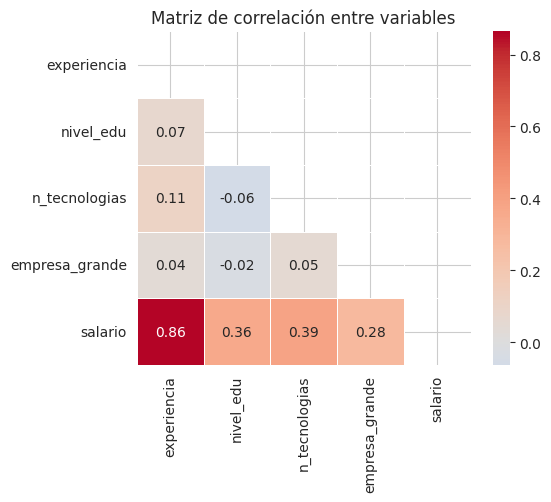

Lectura de la matriz:
  Fila salario → correlación de cada predictor con el salario.
  Resto de celdas → correlación entre predictores (queremos valores bajos).

  → experiencia tiene la correlación más alta con el salario (predictor más fuerte).
  → nivel_edu, n_tecnologias y empresa_grande también correlacionan con el salario.
  → Las correlaciones entre predictores son bajas: sin multicolinealidad. ✓


In [ ]:

plt.figure(figsize=(6, 5))
corr = df.corr()  # calcula la correlación entre todas las variables
mask = np.triu(np.ones_like(corr, dtype=bool))  # oculta el triángulo superior (datos duplicados)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, mask=mask)
plt.title('Matriz de correlación entre variables')
plt.tight_layout()
plt.show()

print('Lectura de la matriz:')
print('  Fila salario → correlación de cada predictor con el salario.')
print('  Resto de celdas → correlación entre predictores (queremos valores bajos).')
print()
print('  → experiencia tiene la correlación más alta con el salario (predictor más fuerte).')
print('  → nivel_edu, n_tecnologias y empresa_grande también correlacionan con el salario.')
print('  → Las correlaciones entre predictores son bajas: sin multicolinealidad. ✓')

# Entrenamos tres modelos y los comparamos

In [ ]:
# ── Modelo 1: solo experiencia (igual que Píldora 1) ──────
X1 = df[['experiencia']].values
Y  = df['salario'].values

# Entrena el modelo y calcula R²
m1 = LinearRegression().fit(X1, Y)
r2_m1 = r2_score(Y, m1.predict(X1))

# Calcula el RMSE: error promedio en las mismas unidades que el salario
rmse_m1 = np.sqrt(mean_squared_error(Y, m1.predict(X1)))

print('Modelo 1 — solo experiencia')
print(f'  Ecuación: Salario = {m1.intercept_:.1f} + {m1.coef_[0]:.1f}·experiencia')
print(f'  R²   = {r2_m1:.4f}  →  explica el {r2_m1*100:.1f}% de la variabilidad salarial')
print(f'  RMSE = {rmse_m1:.2f}  →  error promedio de ±${rmse_m1:.0f}k por predicción')
print()

# ── Modelo 2: experiencia + nivel_edu + n_tecnologias ─────
# Selecciona las 3 variables predictoras del dataframe
X2 = df[['experiencia', 'nivel_edu', 'n_tecnologias']].values

# Entrena y evalúa el modelo 2
m2 = LinearRegression().fit(X2, Y)
r2_m2  = r2_score(Y, m2.predict(X2))
rmse_m2 = np.sqrt(mean_squared_error(Y, m2.predict(X2)))

# Imprime intercepto y coeficiente de cada variable (efecto parcial sobre el salario)
print('Modelo 2 — experiencia + nivel_edu + n_tecnologias')
coefs2 = dict(zip(['experiencia', 'nivel_edu', 'n_tecnologias'], m2.coef_))
print(f'  Intercepto: {m2.intercept_:.1f}')
for var, coef in coefs2.items():
    print(f'  b_{var}: {coef:.2f}')
print(f'  R²   = {r2_m2:.4f}  →  explica el {r2_m2*100:.1f}% de la variabilidad salarial')
print(f'  RMSE = {rmse_m2:.2f}  →  error promedio de ±${rmse_m2:.0f}k por predicción')
print()

# ── Modelo 3: todas las variables ─────────────────────────
# Agrega empresa_grande como cuarto predictor
X3 = df[['experiencia', 'nivel_edu', 'n_tecnologias', 'empresa_grande']].values

# Entrena y evalúa el modelo 3
m3 = LinearRegression().fit(X3, Y)
r2_m3   = r2_score(Y, m3.predict(X3))
rmse_m3 = np.sqrt(mean_squared_error(Y, m3.predict(X3)))

# Imprime coeficientes del modelo completo
# cada uno es el efecto de esa variable manteniendo las demás constantes
print('Modelo 3 — todas las variables')
coefs3 = dict(zip(['experiencia', 'nivel_edu', 'n_tecnologias', 'empresa_grande'], m3.coef_))
print(f'  Intercepto: {m3.intercept_:.1f}')
for var, coef in coefs3.items():
    print(f'  b_{var}: {coef:.2f}')
print(f'  R²   = {r2_m3:.4f}  →  explica el {r2_m3*100:.1f}% de la variabilidad salarial')
print(f'  RMSE = {rmse_m3:.2f}  →  error promedio de ±${rmse_m3:.0f}k por predicción')

Modelo 1 — solo experiencia
  Ecuación: Salario = 586.8 + 58.9·experiencia
  R²   = 0.7473  →  explica el 74.7% de la variabilidad salarial
  RMSE = 150.93  →  error promedio de ±$151k por predicción

Modelo 2 — experiencia + nivel_edu + n_tecnologias
  Intercepto: 224.0
  b_experiencia: 54.92
  b_nivel_edu: 115.20
  b_n_tecnologias: 30.62
  R²   = 0.9380  →  explica el 93.8% de la variabilidad salarial
  RMSE = 74.77  →  error promedio de ±$75k por predicción

Modelo 3 — todas las variables
  Intercepto: 165.2
  b_experiencia: 54.34
  b_nivel_edu: 117.28
  b_n_tecnologias: 29.53
  b_empresa_grande: 148.71
  R²   = 0.9981  →  explica el 99.8% de la variabilidad salarial
  RMSE = 13.07  →  error promedio de ±$13k por predicción


# Interpretación de coeficientes

In [ ]:
# Interpreta en lenguaje natural cada coeficiente del modelo completo
print('=== INTERPRETACIÓN DEL MODELO COMPLETO ===')
print()

# Intercepto: salario estimado cuando todas las variables valen 0 o su mínimo
print(f'  Intercepto ({m3.intercept_:.0f}):')
print(f'  → Salario base estimado (con 0 experiencia, terciario, 0 tecnologías, empresa chica)')
print()

# b_experiencia: efecto parcial de un año más de experiencia sobre el salario
print(f'  Experiencia ({coefs3["experiencia"]:.1f}):')
print(f'  → Por cada año adicional, el salario sube aprox. ${coefs3["experiencia"]:.0f}k')
print(f'    (manteniendo constantes las demás variables)')
print()

# b_nivel_edu: la variable va de 1 a 3, cada punto suma este monto
print(f'  Nivel educativo ({coefs3["nivel_edu"]:.1f}):')
print(f'  → Pasar de terciario (1) a universitario (2) suma aprox. ${coefs3["nivel_edu"]:.0f}k')
print(f'    Pasar a posgrado (3) suma el doble de eso.')
print()

# b_n_tecnologias: efecto parcial de dominar una tecnología más
print(f'  Tecnologías ({coefs3["n_tecnologias"]:.1f}):')
print(f'  → Por cada tecnología adicional que maneja, el salario sube ${coefs3["n_tecnologias"]:.0f}k')
print()

# b_empresa_grande: variable binaria (0=pyme, 1=empresa grande)
print(f'  Empresa grande ({coefs3["empresa_grande"]:.1f}):')
print(f'  → Trabajar en una empresa grande (vs pyme/startup) agrega aprox. ${coefs3["empresa_grande"]:.0f}k')

=== INTERPRETACIÓN DEL MODELO COMPLETO ===

  Intercepto (165):
  → Salario base estimado (con 0 experiencia, terciario, 0 tecnologías, empresa chica)

  Experiencia (54.3):
  → Por cada año adicional, el salario sube aprox. $54k
    (manteniendo constantes las demás variables)

  Nivel educativo (117.3):
  → Pasar de terciario (1) a universitario (2) suma aprox. $117k
    Pasar a posgrado (3) suma el doble de eso.

  Tecnologías (29.5):
  → Por cada tecnología adicional que maneja, el salario sube $30k

  Empresa grande (148.7):
  → Trabajar en una empresa grande (vs pyme/startup) agrega aprox. $149k


# Gráfico 3D del plano

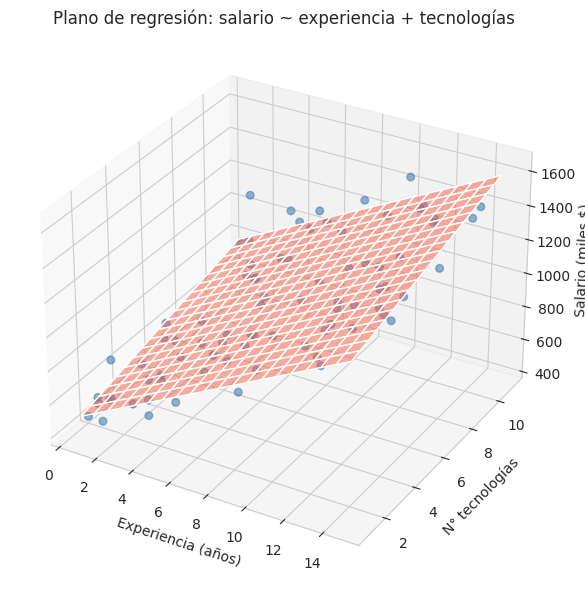

En la regresión simple teníamos una RECTA.
Con 2 predictores tenemos un PLANO.
Con 4 predictores es un HIPERPLANO (misma matemática, no visualizable).


In [ ]:
# ── Visualización 3D: plano de regresión (2 predictores) ──
# Usamos solo experiencia y n_tecnologias para poder graficarlo en 3D
# Con 4 predictores sería un hiperplano (no visualizable)

# Selecciona solo 2 predictores para poder visualizar en 3D
X_viz = df[['experiencia', 'n_tecnologias']].values

# Entrena un modelo auxiliar solo para el gráfico
m_viz = LinearRegression().fit(X_viz, Y)

# Crea el lienzo y el eje 3D
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

# Grafica los datos reales como puntos en el espacio 3D
ax.scatter(df.experiencia, df.n_tecnologias, Y,
           color='steelblue', alpha=0.6, s=30, label='Datos reales')

# Crea una grilla de valores para experiencia y tecnologías
exp_r = np.linspace(df.experiencia.min(), df.experiencia.max(), 20)
tec_r = np.linspace(df.n_tecnologias.min(), df.n_tecnologias.max(), 20)

# Genera todas las combinaciones posibles de experiencia y tecnologías
EXP, TEC = np.meshgrid(exp_r, tec_r)

# Predice el salario para cada punto de la grilla y le da forma de matriz
SAL = m_viz.predict(np.c_[EXP.ravel(), TEC.ravel()]).reshape(EXP.shape)

# Dibuja el plano de regresión sobre los puntos
ax.plot_surface(EXP, TEC, SAL, alpha=0.5, color='tomato')

# Etiquetas de los tres ejes y título
ax.set_xlabel('Experiencia (años)')
ax.set_ylabel('N° tecnologías')
ax.set_zlabel('Salario (miles $)')
ax.set_title('Plano de regresión: salario ~ experiencia + tecnologías')
plt.tight_layout()
plt.show()

print('En la regresión simple teníamos una RECTA.')
print('Con 2 predictores tenemos un PLANO.')
print('Con 4 predictores es un HIPERPLANO (misma matemática, no visualizable).')

# Tabla comparativa de modelos

In [ ]:
# Arma una tabla comparativa de los tres modelos entrenados anteriormente
comparacion = pd.DataFrame({
    'Modelo': ['Solo experiencia', '+ Educación + Tecnologías', '+ Empresa grande'],
    'Variables': [1, 3, 4],                       # cantidad de predictores de cada modelo
    'R²': [r2_m1, r2_m2, r2_m3],                 # R² de cada modelo
    'RMSE': [
        np.sqrt(mean_squared_error(Y, m1.predict(X1))),  # error promedio modelo 1
        np.sqrt(mean_squared_error(Y, m2.predict(X2))),  # error promedio modelo 2
        np.sqrt(mean_squared_error(Y, m3.predict(X3)))   # error promedio modelo 3
    ]
})

# Redondea para mejorar la legibilidad de la tabla
comparacion['R²']   = comparacion['R²'].round(4)
comparacion['RMSE'] = comparacion['RMSE'].round(2)

print('=== COMPARACIÓN DE MODELOS ===')
print(comparacion.to_string(index=False))
print()
print('→ Agregar variables relevantes mejora el R² y reduce el RMSE.')
print('→ Pero agregar variables irrelevantes también sube el R² artificialmente.')
print('  Por eso existe el R² AJUSTADO — que penaliza variables que no aportan.')

=== COMPARACIÓN DE MODELOS ===
                   Modelo  Variables     R²   RMSE
         Solo experiencia          1 0.7473 150.93
+ Educación + Tecnologías          3 0.9380  74.77
         + Empresa grande          4 0.9981  13.07

→ Agregar variables relevantes mejora el R² y reduce el RMSE.
→ Pero agregar variables irrelevantes también sube el R² artificialmente.
  Por eso existe el R² AJUSTADO — que penaliza variables que no aportan.


#  Predicciones por perfil

In [ ]:
# Define tres perfiles de profesionales con sus características
perfiles = pd.DataFrame({
    'perfil':         ['Junior universitario', 'Senior con posgrado', 'Tech Lead empresa grande'],
    'experiencia':    [1,   8,  12],  # años de experiencia
    'nivel_edu':      [2,   3,   3],  # 2=universitario, 3=posgrado
    'n_tecnologias':  [2,   6,   9],  # cantidad de tecnologías que maneja
    'empresa_grande': [0,   0,   1]   # 0=pyme/startup, 1=empresa grande
})

# Extrae solo las columnas predictoras para pasarlas al modelo
X_pred = perfiles[['experiencia', 'nivel_edu', 'n_tecnologias', 'empresa_grande']].values

# Usa el modelo 3 (el más completo) para estimar el salario de cada perfil
perfiles['salario_estimado'] = m3.predict(X_pred).round(0)

# Imprime las predicciones por perfil
print('=== PREDICCIONES POR PERFIL ===')
for _, row in perfiles.iterrows():
    print(f"  {row['perfil']:38s} → ${row['salario_estimado']:.0f}k/mes")

# Calcula el RMSE del modelo 3 para mostrar el margen de error
rmse_m3 = np.sqrt(mean_squared_error(Y, m3.predict(X3)))
print(f'\n  (Margen de error del modelo: ±${rmse_m3:.0f}k)')

# Análisis de residuos

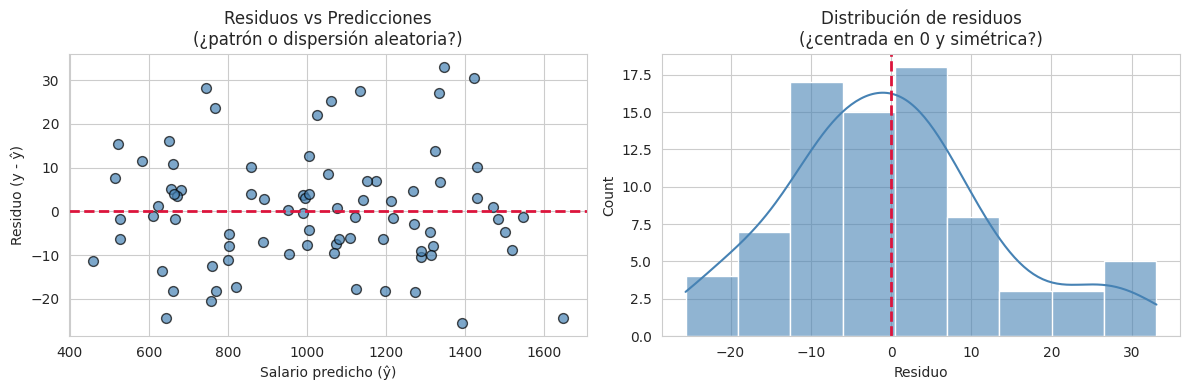

Media de los residuos: -0.0000  (debería ser ≈ 0)
Si el gráfico de residuos vs predicciones no muestra patrón → homocedasticidad OK


In [ ]:
# Calcula las predicciones y los residuos del modelo completo
Y_pred_m3 = m3.predict(X3)
res_m3 = Y - Y_pred_m3  # residuo = valor real − valor predicho

# Crea dos gráficos side by side para analizar los residuos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Gráfico 1: Residuos vs Predicciones ──────────────────
# Si hay un patrón (curva, embudo) → el modelo tiene problemas
# Si es dispersión aleatoria → homocedasticidad cumplida
axes[0].scatter(Y_pred_m3, res_m3, color='steelblue', alpha=0.7, edgecolors='k', s=50)
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=2)  # línea de referencia en 0
axes[0].set_xlabel('Salario predicho (ŷ)')
axes[0].set_ylabel('Residuo (y - ŷ)')
axes[0].set_title('Residuos vs Predicciones\n(¿patrón o dispersión aleatoria?)')

# ── Gráfico 2: Histograma de residuos ────────────────────
# Debe tener forma de campana centrada en 0 → normalidad cumplida
sns.histplot(res_m3, kde=True, color='steelblue', alpha=0.6, ax=axes[1])
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=2)  # línea de referencia en 0
axes[1].set_xlabel('Residuo')
axes[1].set_title('Distribución de residuos\n(¿centrada en 0 y simétrica?)')

plt.tight_layout()
plt.show()

# Verifica numéricamente que la media de los residuos sea ≈ 0
print(f'Media de los residuos: {np.mean(res_m3):.4f}  (debería ser ≈ 0)')
print('Si el gráfico de residuos vs predicciones no muestra patrón → homocedasticidad OK')

# El nuevo supuesto: no multicolinealidad

La regresión múltiple agrega un supuesto a los cuatro de la regresión simple:

> **No multicolinealidad:** las variables independientes no deben estar altamente correlacionadas entre sí.

**¿Qué pasa si hay multicolinealidad?**

Imaginá que tenés dos predictores casi idénticos: por ejemplo, `experiencia` y `antigüedad_en_empresa`. En muchos casos van de la mano. El modelo no puede determinar cuánto aporta cada uno por separado — los coeficientes se vuelven inestables y cambian mucho con pequeñas variaciones en los datos.

**¿Cómo detectarla?**
- Matriz de correlación entre predictores (valores |r| > 0.8 son señal de alerta)
- Factor de Inflación de la Varianza (VIF) — lo veremos en la clase sincrónica

**¿Cómo resolverla?**
- Eliminar una de las variables redundantes
- Usar técnicas de regularización (Píldora 3)

##  Resumen

| Concepto | En nuestro ejemplo |
|----------|-------------------|
| Variable dependiente Y | Salario mensual |
| Variables independientes X | Experiencia, educación, tecnologías, empresa |
| Coeficiente parcial bⱼ | Efecto de Xⱼ sobre el salario, *manteniendo las demás constantes* |
| Geometría del modelo | Recta (1 predictor) → Plano (2) → Hiperplano (k) |
| Multicolinealidad | Si dos predictores están muy correlacionados, el modelo se inestabiliza |
| R² ajustado | Penaliza agregar variables que no aportan|

---
---
*Ciencia de Datos · CLCD 121 · Universidad del Gran Rosario*